<a href="https://colab.research.google.com/github/Tanishq-009/ImpactSense/blob/main/earthquake_dataset_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import files
uploaded = files.upload()

Saving earthquake_alert_balanced_dataset.csv to earthquake_alert_balanced_dataset (3).csv


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv('earthquake_alert_balanced_dataset.csv')
data = pd.DataFrame(data)


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  1300 non-null   float64
 1   depth      1300 non-null   float64
 2   cdi        1300 non-null   float64
 3   mmi        1300 non-null   float64
 4   sig        1300 non-null   float64
 5   alert      1300 non-null   object 
dtypes: float64(5), object(1)
memory usage: 61.1+ KB


In [10]:
data.describe()

,magnitude,depth,cdi,mmi,sig
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000
mean,7.061008,50.321538,6.976154,6.939231,-9.749231
std,0.423738,104.348286,2.244875,1.354774,62.245214
min,6.500000,2.000000,0.000000,1.000000,-128.000000
25%,6.700000,12.000000,6.000000,6.000000,-54.000000
50%,7.000000,19.000000,8.000000,7.000000,-7.000000
75%,7.300000,38.000000,8.000000,8.000000,31.000000
max,8.600000,670.000000,9.000000,9.000000,127.000000


In [11]:
data.dropna()

,magnitude,depth,cdi,mmi,sig,alert
0,7.00,14.0,8.0,7.0,0.0,green
1,6.90,25.0,4.0,4.0,-33.0,green
2,7.00,579.0,3.0,3.0,-13.0,green
3,7.30,37.0,5.0,5.0,65.0,green
4,6.60,624.0,0.0,2.0,-98.0,green
...,...,...,...,...,...,...
1295,6.87,11.0,9.0,7.0,13.0,yellow
1296,7.85,93.0,8.0,6.0,-51.0,yellow
1297,7.48,142.0,7.0,6.0,120.0,yellow
1298,7.04,51.0,7.0,6.0,-115.0,yellow


In [12]:
data.drop_duplicates()

,magnitude,depth,cdi,mmi,sig,alert
0,7.00,14.0,8.0,7.0,0.0,green
1,6.90,25.0,4.0,4.0,-33.0,green
2,7.00,579.0,3.0,3.0,-13.0,green
3,7.30,37.0,5.0,5.0,65.0,green
4,6.60,624.0,0.0,2.0,-98.0,green
...,...,...,...,...,...,...
1295,6.87,11.0,9.0,7.0,13.0,yellow
1296,7.85,93.0,8.0,6.0,-51.0,yellow
1297,7.48,142.0,7.0,6.0,120.0,yellow
1298,7.04,51.0,7.0,6.0,-115.0,yellow


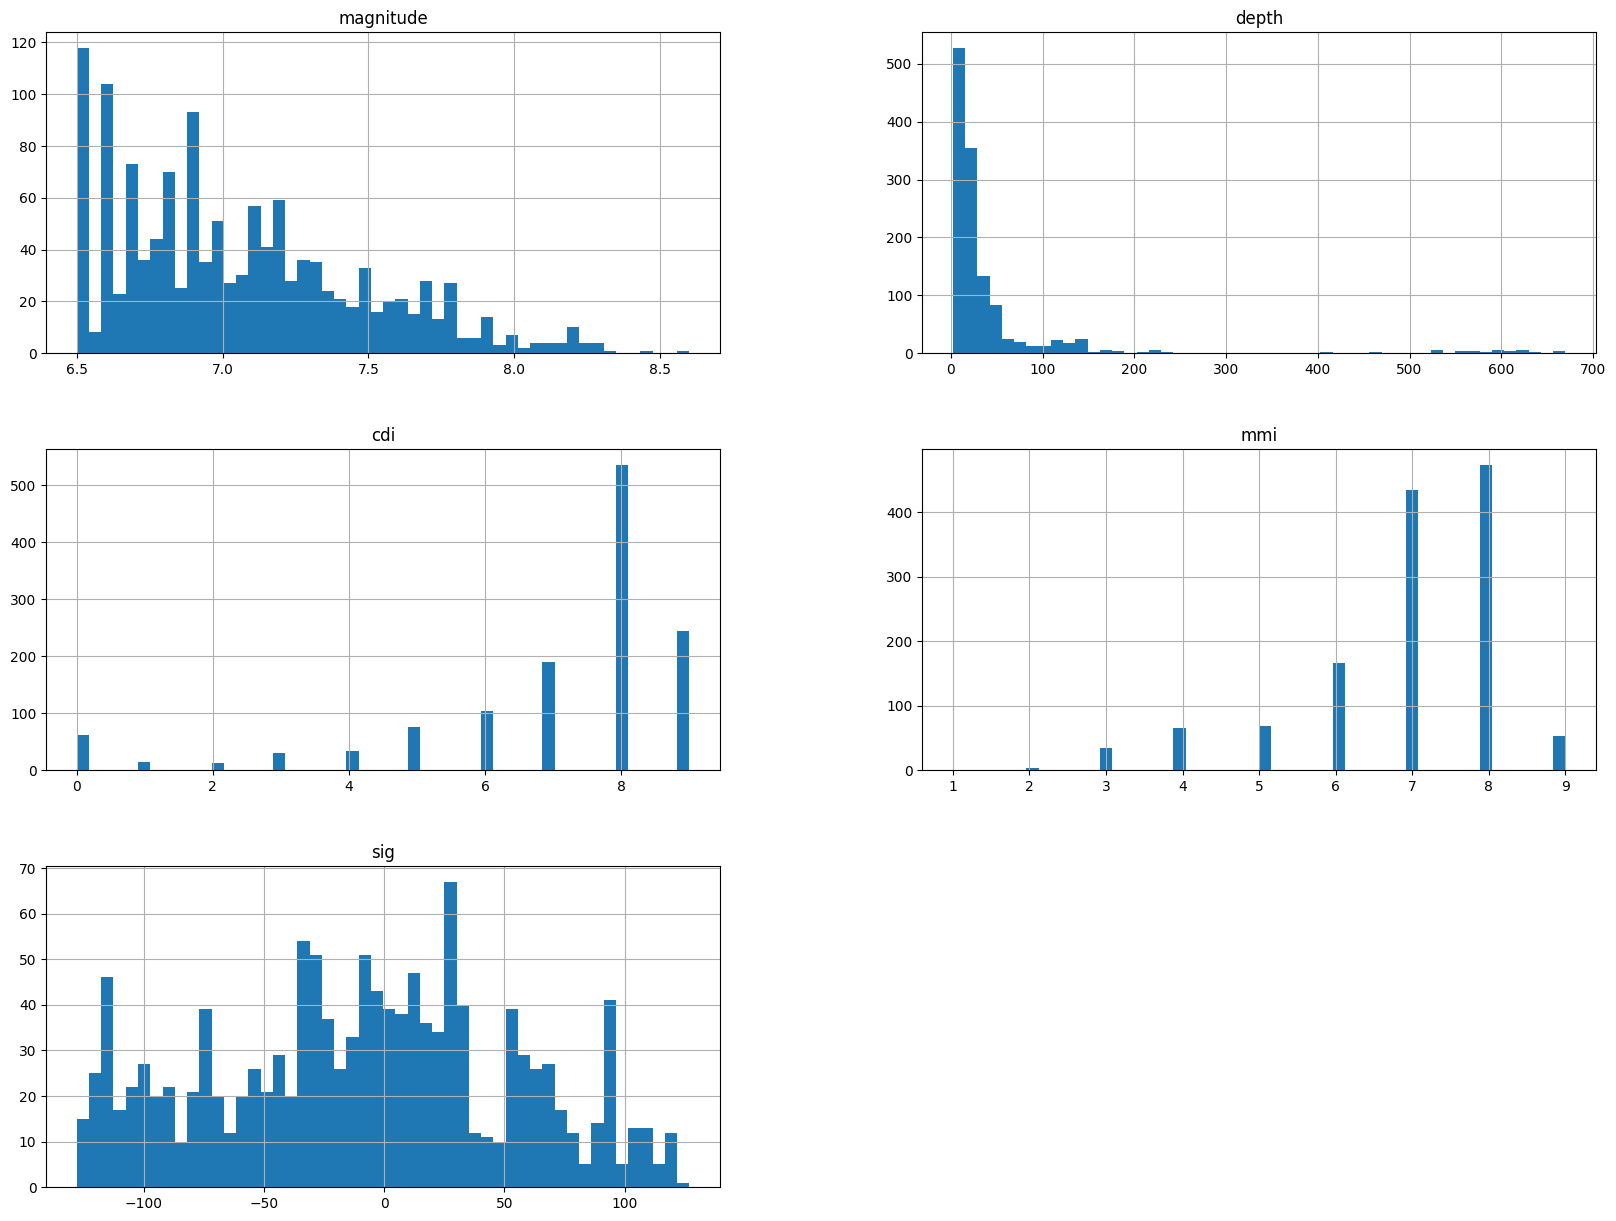

In [13]:
data.hist(bins=50, figsize=(20,15))
plt.show()

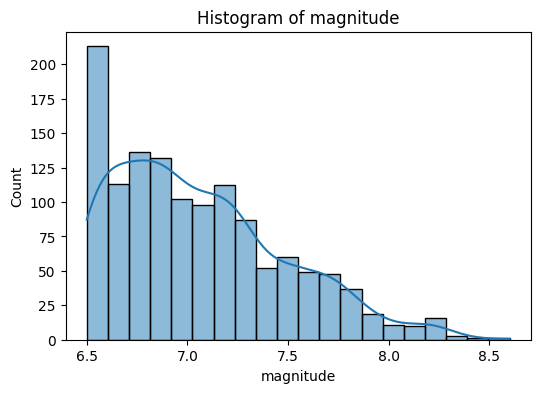

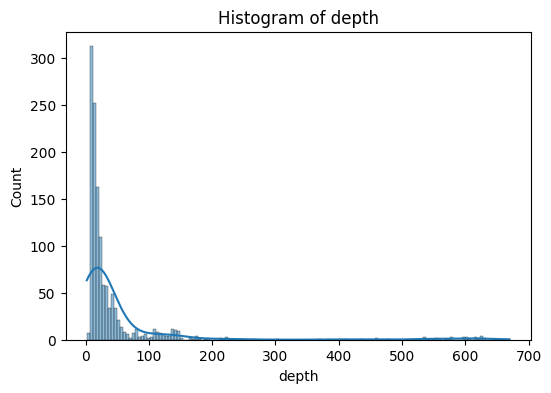

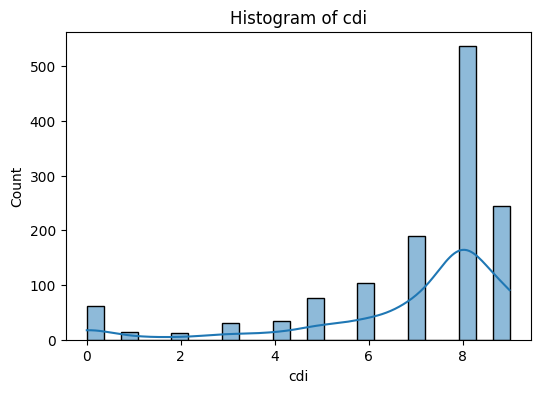

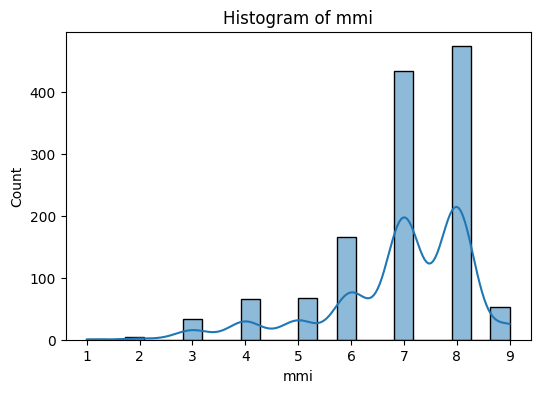

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(data['magnitude'], kde=True)
plt.title('Histogram of magnitude')
plt.show()
plt.figure(figsize=(6,4))
sns.histplot(data['depth'], kde=True)
plt.title('Histogram of depth')
plt.show()
plt.figure(figsize=(6,4))
sns.histplot(data['cdi'], kde=True)
plt.title('Histogram of cdi')
plt.show()
plt.figure(figsize=(6,4))
sns.histplot(data['mmi'], kde=True)
plt.title('Histogram of mmi')
plt.show()

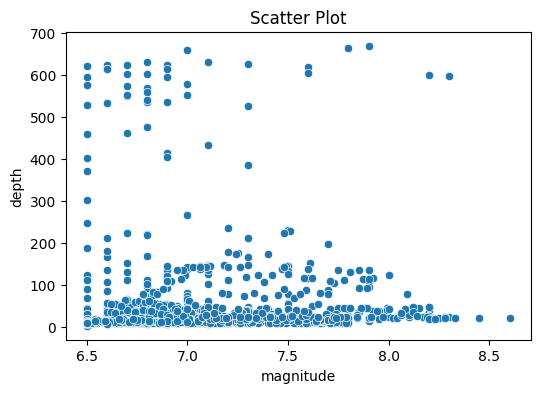

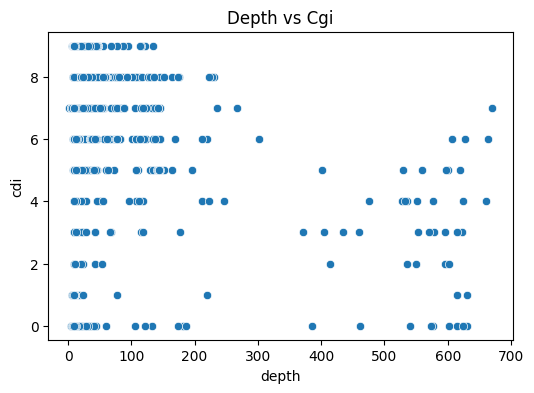

In [15]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=data['magnitude'], y=data['depth'])
plt.title('Scatter Plot')
plt.show()
plt.figure(figsize=(6,4))
sns.scatterplot(x=data['depth'], y=data['cdi'])
plt.title('Depth vs Cgi')
plt.show()

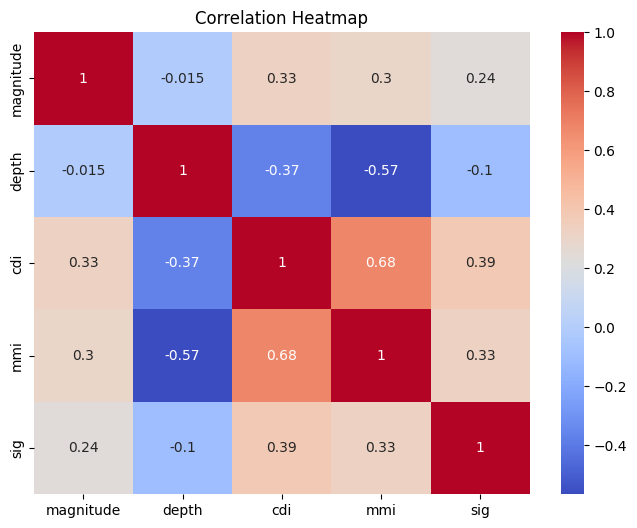

In [16]:
plt.figure(figsize=(8,6))
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [17]:
import plotly.express as px

fig = px.scatter_3d(
    data,
    x='depth',
    y='magnitude',
    z='sig',
    color='magnitude',
    title='3D View: Depth vs Magnitude vs Significance'
)

fig.show()




In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

data = pd.read_csv("earthquake_alert_balanced_dataset.csv")

numeric_cols = data.select_dtypes(include=np.number).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

categorical_cols = data.select_dtypes(include="object").columns
for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])


data.drop_duplicates(inplace=True)

if "magnitude" in data.columns and "depth" in data.columns:
    data["mag_depth_interaction"] = data["magnitude"] * data["depth"]

if "magnitude" in data.columns:
    data["energy_approx"] = 10 ** (1.5 * data["magnitude"])


label_encoder = LabelEncoder()
data["alert"] = label_encoder.fit_transform(data["alert"])

X = data.drop("alert", axis=1)
y = data["alert"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

final_data = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)

final_data.to_csv("earthquake_preprocessed_week2.csv", index=False)


In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report



data = pd.read_csv("earthquake_preprocessed_week2.csv")

X = data.drop("alert", axis=1)
y = data["alert"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, log_pred))

Logistic Regression Accuracy: 0.6507936507936508


In [21]:

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, tree_pred))

Decision Tree Accuracy: 0.8849206349206349


In [22]:
from sklearn.metrics import mean_absolute_error

log_mae = mean_absolute_error(y_test, log_pred)

tree_mae = mean_absolute_error(y_test, tree_pred)

print("Logistic Regression MAE:", log_mae)
print("Decision Tree MAE:", tree_mae)

Logistic Regression MAE: 0.6547619047619048
Decision Tree MAE: 0.25


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

data = pd.read_csv("earthquake_preprocessed_week2.csv")

X = data.drop("alert", axis=1)
y = data["alert"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:",
      accuracy_score(y_test, gb_pred))

Random Forest Accuracy: 0.9126984126984127
Gradient Boosting Accuracy: 0.8928571428571429


In [24]:
rf_cv = cross_val_score(rf_model, X, y, cv=5)
gb_cv = cross_val_score(gb_model, X, y, cv=5)

print("Random Forest CV Accuracy:", rf_cv.mean())
print("Gradient Boosting CV Accuracy:", gb_cv.mean())

Random Forest CV Accuracy: 0.9084392588376652
Gradient Boosting CV Accuracy: 0.8773920192246886


In [26]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

best_rf = grid_search.best_estimator_

best_pred = best_rf.predict(X_test)

print("Tuned Random Forest Accuracy:",
      accuracy_score(y_test, best_pred))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Tuned Random Forest Accuracy: 0.9126984126984127
